<a href="https://colab.research.google.com/github/DB2557/DL_202511057_Dhara/blob/main/LAB3/lab3_DL_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IT549: Deep Learning – Lab 3
## Image-Based AQI Classification using CNN and Pretrained Models

**Name:** [Your Name]  
**ID:** [Your ID]

## Setup

In [1]:
!pip install -q torch torchvision scikit-learn matplotlib seaborn pillow

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image, UnidentifiedImageError
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
warnings.filterwarnings("ignore")

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
set_seed()

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 1e-3
NUM_FREEZE = 10
print("Device:", DEVICE)

Device: cuda


## Paths — update these to match your Drive layout

In [12]:
CSV_PATH = "/content/drive/MyDrive/DL/lab3/data.csv"
IMG_DIR  = "/content/drive/MyDrive/DL/Lab3/sampled_images"
OUT_DIR  = "/content/results"
os.makedirs(OUT_DIR, exist_ok=True)

In [15]:
df = pd.read_csv(CSV_PATH)
df = df[["Filename", "AQI_Class"]].rename(columns={"Filename": "image_path"})
df["full_path"] = df["image_path"].apply(lambda x: os.path.join(IMG_DIR, x))
df = df[df["full_path"].apply(os.path.exists)].reset_index(drop=True)
print(f"Valid samples: {len(df)}")
print(df["AQI_Class"].value_counts())


Valid samples: 6000
AQI_Class
a_Good                              1000
b_Moderate                          1000
c_Unhealthy_for_Sensitive_Groups    1000
d_Unhealthy                         1000
e_Very_Unhealthy                    1000
f_Severe                            1000
Name: count, dtype: int64


## Task 1 – Data Preparation

In [16]:
# Auto-detect image folder
ACTUAL_IMG_DIR = None
for root, dirs, files in os.walk(IMG_DIR):
    if any(f.endswith(".jpg") for f in files):
        ACTUAL_IMG_DIR = root
        break

print("Images found at:", ACTUAL_IMG_DIR)

df = pd.read_csv(CSV_PATH)
df = df[["Filename", "AQI_Class"]].rename(columns={"Filename": "image_path"})

# Build a lookup from filename → full path
path_lookup = {}
for root, dirs, files in os.walk(ACTUAL_IMG_DIR):
    for f in files:
        path_lookup[f] = os.path.join(root, f)

df["full_path"] = df["image_path"].map(path_lookup)
df = df[df["full_path"].notna()].reset_index(drop=True)
print(f"Valid samples: {len(df)}")
print(df["AQI_Class"].value_counts())

classes      = sorted(df["AQI_Class"].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
NUM_CLASSES  = len(classes)
df["label"]  = df["AQI_Class"].map(class_to_idx)

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df["label"])
val_df,   test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"])
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Images found at: /content/drive/MyDrive/DL/lab3/sampled_images
Valid samples: 6000
AQI_Class
a_Good                              1000
b_Moderate                          1000
c_Unhealthy_for_Sensitive_Groups    1000
d_Unhealthy                         1000
e_Very_Unhealthy                    1000
f_Severe                            1000
Name: count, dtype: int64
Train: 4200 | Val: 900 | Test: 900


In [17]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class AQIDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        try:    img = Image.open(row["full_path"]).convert("RGB")
        except: img = Image.fromarray(np.zeros((IMG_SIZE,IMG_SIZE,3),dtype=np.uint8))
        if self.transform: img = self.transform(img)
        return img, int(row["label"])

train_loader = DataLoader(AQIDataset(train_df, train_transform), BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(AQIDataset(val_df,   eval_transform),  BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(AQIDataset(test_df,  eval_transform),  BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("Loaders ready")

Loaders ready


## Task 2 – Basic CNN (from scratch)

In [18]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,   32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32,  64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(True), nn.MaxPool2d(2),
        )
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(256,256), nn.ReLU(True), nn.Dropout(0.5), nn.Linear(256, num_classes)
        )
    def forward(self, x): return self.classifier(self.pool(self.features(x)))

basic_cnn = BasicCNN(NUM_CLASSES).to(DEVICE)
print(f"BasicCNN params: {sum(p.numel() for p in basic_cnn.parameters()):,}")

BasicCNN params: 456,710


## Task 3 – ResNet-18 Transfer Learning (freeze 10 / 18 layers)

In [19]:
def build_resnet18(num_classes, freeze_n=10):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    conv_layers = [(n,m) for n,m in model.named_children() if n != "fc"]
    for idx, (name, module) in enumerate(conv_layers):
        req = idx >= freeze_n
        for p in module.parameters(): p.requires_grad = req
        print(f"  [{idx:02d}] {'TRAINABLE' if req else 'FROZEN   '}  {name}")
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256), nn.ReLU(True), nn.Dropout(0.4), nn.Linear(256, num_classes)
    )
    return model

resnet18  = build_resnet18(NUM_CLASSES, NUM_FREEZE).to(DEVICE)
trainable = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
total     = sum(p.numel() for p in resnet18.parameters())
print(f"Trainable / Total: {trainable:,} / {total:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 143MB/s]


  [00] FROZEN     conv1
  [01] FROZEN     bn1
  [02] FROZEN     relu
  [03] FROZEN     maxpool
  [04] FROZEN     layer1
  [05] FROZEN     layer2
  [06] FROZEN     layer3
  [07] FROZEN     layer4
  [08] FROZEN     avgpool
Trainable / Total: 132,870 / 11,309,382


## Task 4 – Training & Evaluation

In [20]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum, correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        loss_sum += loss.item()*imgs.size(0)
        correct  += (out.argmax(1)==labels).sum().item()
        n        += imgs.size(0)
    return loss_sum/n, correct/n

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out  = model(imgs)
        loss = criterion(out, labels)
        loss_sum += loss.item()*imgs.size(0)
        correct  += (out.argmax(1)==labels).sum().item()
        n        += imgs.size(0)
    return loss_sum/n, correct/n

@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    preds, lbls = [], []
    for imgs, labels in loader:
        preds.extend(model(imgs.to(DEVICE)).argmax(1).cpu().numpy())
        lbls.extend(labels.numpy())
    return np.array(preds), np.array(lbls)

def train_model(model, name, epochs=EPOCHS, lr=LR):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history   = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[]}
    best_acc, best_state, wait = 0.0, None, 0

    print(f"\nTraining {name}")
    print(f"{'Epoch':>6} {'T-Loss':>8} {'T-Acc':>7} {'V-Loss':>8} {'V-Acc':>7}")
    for ep in range(1, epochs+1):
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer)
        vl, va = evaluate(model, val_loader, criterion)
        scheduler.step()
        for k,v in zip(history, [tl,vl,ta,va]): history[k].append(v)
        print(f"{ep:>6} {tl:>8.4f} {ta:>7.4f} {vl:>8.4f} {va:>7.4f}")
        if va > best_acc:
            best_acc, best_state, wait = va, {k:v.cpu().clone() for k,v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= 5: print(f"  Early stop at epoch {ep}"); break
    model.load_state_dict(best_state)
    torch.save(model.state_dict(), f"{OUT_DIR}/{name}_best.pt")
    print(f"  Saved best weights (val_acc={best_acc:.4f})")
    return history

history_cnn = train_model(basic_cnn, "BasicCNN")
history_tl  = train_model(resnet18,  "ResNet18_TL")


Training BasicCNN
 Epoch   T-Loss   T-Acc   V-Loss   V-Acc
     1   1.4916  0.3786   1.2664  0.4711
     2   1.2794  0.4917   1.2208  0.5233
     3   1.1756  0.5383   1.1100  0.5533
     4   1.0888  0.5664   1.0499  0.5744
     5   1.0196  0.5952   0.8901  0.6322
     6   0.9835  0.6033   0.9003  0.6222
     7   0.9532  0.6226   0.8919  0.6289
     8   0.9253  0.6448   0.7924  0.6711
     9   0.8607  0.6490   0.7588  0.7011
    10   0.8419  0.6583   0.7111  0.6922
    11   0.7970  0.6840   0.6591  0.7056
    12   0.7583  0.6986   0.7469  0.6789
    13   0.7601  0.6986   0.6498  0.7156
    14   0.7177  0.7152   0.7033  0.7078
    15   0.7079  0.7119   0.6000  0.7400
    16   0.6822  0.7338   0.6192  0.7367
    17   0.6670  0.7426   0.5585  0.7756
    18   0.6565  0.7510   0.5542  0.7756
    19   0.6405  0.7462   0.5533  0.7833
    20   0.6383  0.7476   0.5466  0.7822
  Saved best weights (val_acc=0.7833)

Training ResNet18_TL
 Epoch   T-Loss   T-Acc   V-Loss   V-Acc
     1   1.4527  0.

In [21]:
def print_metrics(preds, labels, name):
    m = {
        "acc":       accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall":    recall_score(labels, preds, average="weighted", zero_division=0),
        "f1":        f1_score(labels, preds, average="weighted", zero_division=0),
    }
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    for k,v in m.items(): print(f"  {k:10s}: {v:.4f}")
    print(classification_report(labels, preds, target_names=classes, zero_division=0))
    return m

cnn_preds, cnn_labels = get_predictions(basic_cnn, test_loader)
tl_preds,  tl_labels  = get_predictions(resnet18,  test_loader)

cnn_metrics = print_metrics(cnn_preds, cnn_labels, "BasicCNN")
tl_metrics  = print_metrics(tl_preds,  tl_labels,  "ResNet-18 TL")


BasicCNN
  acc       : 0.7744
  precision : 0.7729
  recall    : 0.7744
  f1        : 0.7672
                                  precision    recall  f1-score   support

                          a_Good       0.78      0.86      0.82       150
                      b_Moderate       0.74      0.77      0.75       150
c_Unhealthy_for_Sensitive_Groups       0.69      0.44      0.54       150
                     d_Unhealthy       0.68      0.82      0.74       150
                e_Very_Unhealthy       0.87      0.83      0.85       150
                        f_Severe       0.88      0.93      0.90       150

                        accuracy                           0.77       900
                       macro avg       0.77      0.77      0.77       900
                    weighted avg       0.77      0.77      0.77       900


ResNet-18 TL
  acc       : 0.7689
  precision : 0.7726
  recall    : 0.7689
  f1        : 0.7681
                                  precision    recall  f1-score  

## Task 5 – Training Curves

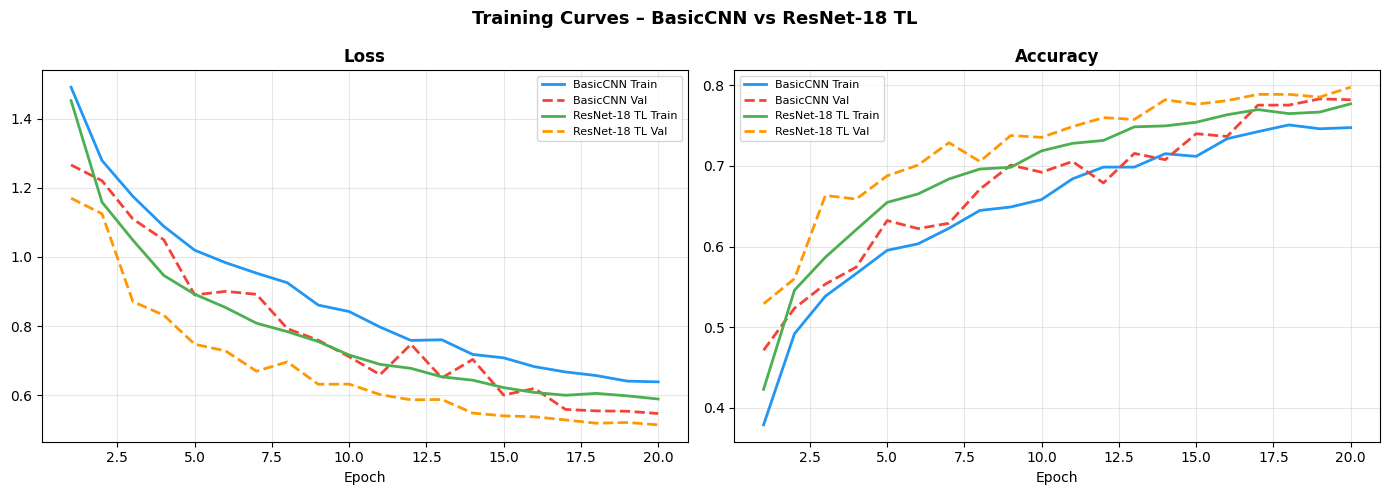

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training Curves – BasicCNN vs ResNet-18 TL", fontsize=13, fontweight="bold")

for ax, metric, title in zip(axes, ["loss","acc"], ["Loss","Accuracy"]):
    for h, name, c1, c2 in [
        (history_cnn, "BasicCNN",  "#2196F3","#F44336"),
        (history_tl,  "ResNet-18 TL","#4CAF50","#FF9800"),
    ]:
        ep = range(1, len(h[f"train_{metric}"])+1)
        ax.plot(ep, h[f"train_{metric}"], color=c1, lw=2, label=f"{name} Train")
        ax.plot(ep, h[f"val_{metric}"],   color=c2, lw=2, linestyle="--", label=f"{name} Val")
    ax.set_title(title, fontweight="bold"); ax.set_xlabel("Epoch"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

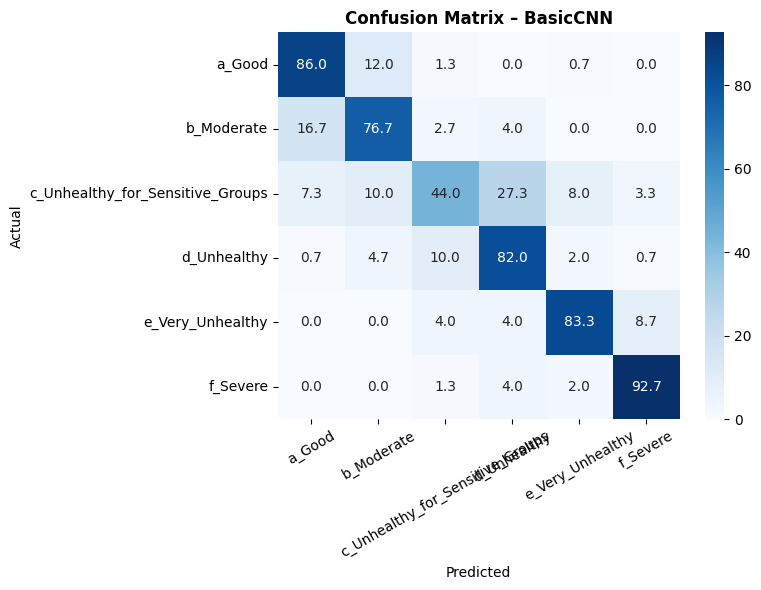

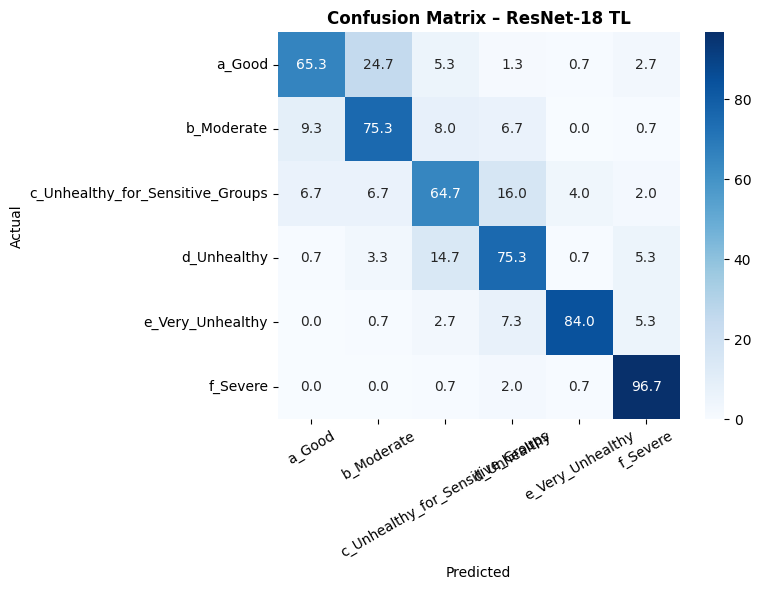

In [23]:
def plot_cm(preds, labels, title, fname):
    cm  = confusion_matrix(labels, preds)
    pct = cm / cm.sum(axis=1, keepdims=True) * 100
    fig, ax = plt.subplots(figsize=(8,6))
    sns.heatmap(pct, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f"Confusion Matrix – {title}", fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/{fname}", dpi=150, bbox_inches="tight")
    plt.show()

plot_cm(cnn_preds, cnn_labels, "BasicCNN",         "cm_cnn.png")
plot_cm(tl_preds,  tl_labels,  "ResNet-18 TL",     "cm_resnet18.png")

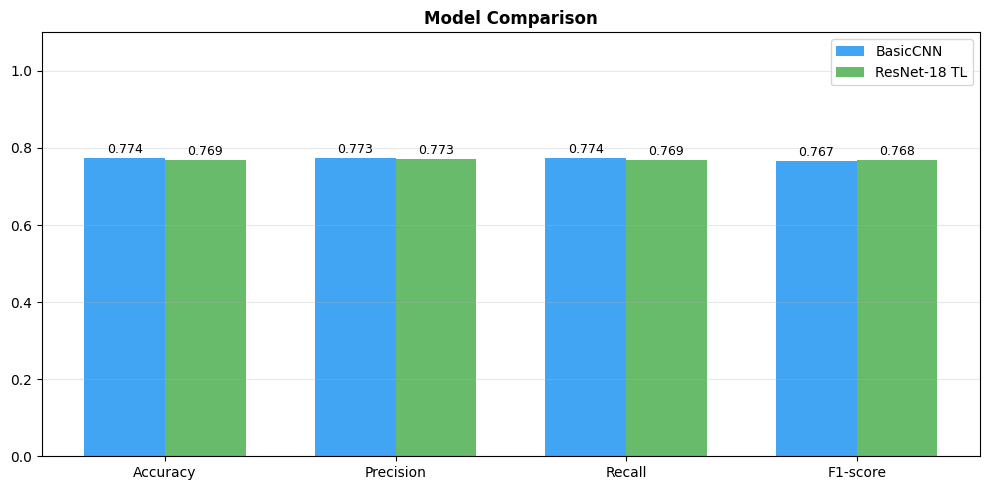

In [24]:
metrics_list = ["acc","precision","recall","f1"]
x = np.arange(len(metrics_list)); w = 0.35
fig, ax = plt.subplots(figsize=(10,5))
b1 = ax.bar(x-w/2, [cnn_metrics[k] for k in metrics_list], w, label="BasicCNN",    color="#2196F3", alpha=0.85)
b2 = ax.bar(x+w/2, [tl_metrics[k]  for k in metrics_list], w, label="ResNet-18 TL",color="#4CAF50", alpha=0.85)
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
            f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(["Accuracy","Precision","Recall","F1-score"])
ax.set_ylim(0,1.1); ax.set_title("Model Comparison", fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 6 – Misclassification Analysis

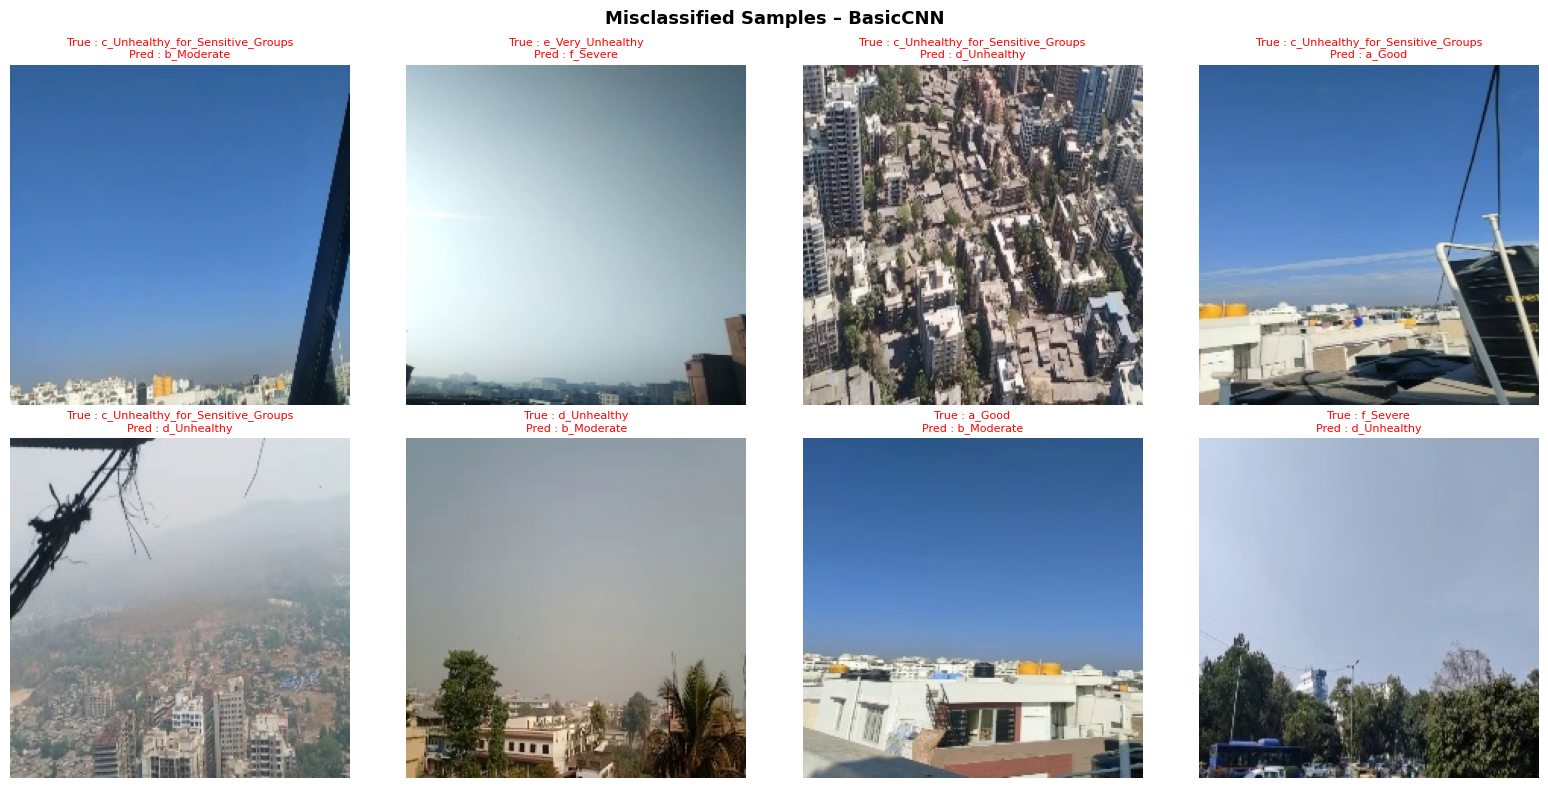

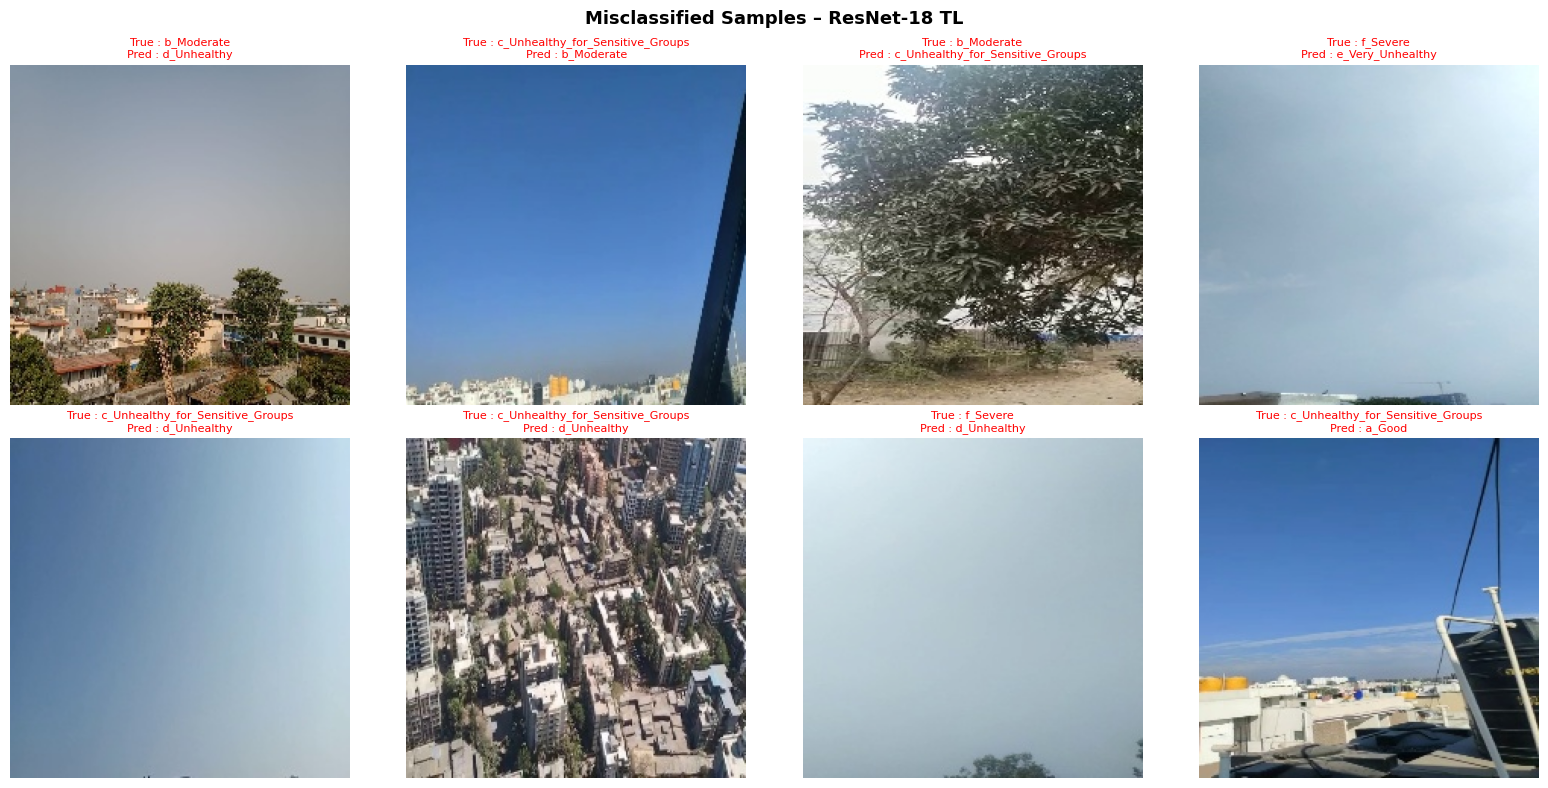

In [25]:
INV = transforms.Compose([
    transforms.Normalize([0,0,0],[1/0.229,1/0.224,1/0.225]),
    transforms.Normalize([-0.485,-0.456,-0.406],[1,1,1]),
])

def show_misclassified(model, loader, name, fname, n=8):
    model.eval()
    imgs_out, preds_out, labels_out = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            out  = model(imgs.to(DEVICE)).argmax(1).cpu()
            mask = out != labels
            for i, m in enumerate(mask):
                if m:
                    imgs_out.append(imgs[i]); preds_out.append(out[i].item()); labels_out.append(labels[i].item())
            if len(imgs_out) >= n: break

    k = min(n, len(imgs_out))
    if k == 0: print(f"{name}: no misclassifications!"); return

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f"Misclassified Samples – {name}", fontsize=13, fontweight="bold")
    for i, ax in enumerate(axes.flatten()):
        if i >= k: ax.axis("off"); continue
        img = np.clip(INV(imgs_out[i]).permute(1,2,0).numpy(), 0, 1)
        ax.imshow(img)
        ax.set_title(f"True : {idx_to_class[labels_out[i]]}\nPred : {idx_to_class[preds_out[i]]}",
                     fontsize=8, color="red")
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/{fname}", dpi=150, bbox_inches="tight")
    plt.show()

show_misclassified(basic_cnn, test_loader, "BasicCNN",    "misclassified_cnn.png")
show_misclassified(resnet18,  test_loader, "ResNet-18 TL","misclassified_resnet18.png")

### Misclassification Discussion

- **Adjacent AQI classes** (e.g. Good vs Moderate) share very similar visual appearances — hazy vs slightly hazy skies are hard to distinguish even for humans.
- **Lighting and weather variation** (overcast days, sunset tones) can push pixel distributions across class boundaries.
- **ResNet-18 misclassifies less** because its frozen early layers already extract robust low-level features (edges, textures, sky colour gradients) from ImageNet pre-training.

In [26]:
summary = pd.DataFrame({
    "Model"    : ["BasicCNN (scratch)", "ResNet-18 (TL, freeze=10)"],
    "Accuracy" : [cnn_metrics["acc"],       tl_metrics["acc"]],
    "Precision": [cnn_metrics["precision"], tl_metrics["precision"]],
    "Recall"   : [cnn_metrics["recall"],    tl_metrics["recall"]],
    "F1-score" : [cnn_metrics["f1"],        tl_metrics["f1"]],
})
display(summary)
summary.to_csv(f"{OUT_DIR}/results_summary.csv", index=False)
print("All results saved to", OUT_DIR)

,Model,Accuracy,Precision,Recall,F1-score
0,BasicCNN (scratch),0.774444,0.772901,0.774444,0.767205
1,"ResNet-18 (TL, freeze=10)",0.768889,0.772609,0.768889,0.768058


All results saved to /content/results
